# Important to run this notebook
A `.env` file at the root of this repository that defines `PYTHONPATH=src/python` is required to have the correct module resolution.

In [1]:
from typing import Literal
import matplotlib.pyplot as plt
import polars as pl
import numpy as np
from results import Result


def compute_xmax(results: list[Result], by: Literal["time", "step"] = "time"):
    if by == "time":
        return max(r.t_max for r in results)
    elif by == "step":
        return max(r.step_max for r in results)
    else:
        raise ValueError(f"Unknown by value: {by}")


def compute_primal_gaps(results: list[Result], by: Literal["time", "step"] = "time"):
    tmax = compute_xmax(results, by=by)
    objs = [r.primal_gap_array(by=by, tmax=int(tmax) + 1) for r in results]
    return np.array(objs, dtype=np.float32)


def compute_objectives(results: list[Result], by: Literal["time", "step"] = "time"):
    tmax = compute_xmax(results, by=by)
    objs = [r.objective_array(by=by, tmax=int(tmax) + 1) for r in results]
    return np.array(objs, dtype=np.float32)


def plot_by_bandit(
    df: pl.DataFrame,
    metric: Literal["primal gap", "objective"] = "primal gap",
    auto_ylim: bool = True,
    x_axis: Literal["time", "step"] = "time",
):
    ymin, ymax, xmax = float("inf"), float("-inf"), 0
    data = dict[str, tuple[np.ndarray, np.ndarray]]()
    for (name, *_), bandit in df.group_by(pl.col("bandit")):
        print(f"Processing {name} ({bandit.height} results)")
        results = [Result(**row) for row in bandit.iter_rows(named=True)]
        match metric:
            case "primal gap":
                arr = compute_primal_gaps(results, by=x_axis)
            case "objective":
                arr = compute_objectives(results, by=x_axis)
            case other:
                raise ValueError(f"Unknown metric {other}")
        mean, std = arr.mean(axis=0), arr.std(axis=0)
        ci95 = 1.96 * std / len(results)**0.5
        xmax = max(xmax, len(mean))
        if auto_ylim:
            istart = int(-len(mean) // 2)
            ymin = min(ymin, (mean[istart:] - ci95[istart:]).min())
            ymax = max(ymax, (mean[istart:] + ci95[istart:]).max())
        data[name] = (mean, ci95)

    xs = np.arange(xmax)
    for name, (mean, ci95) in data.items():
        mean = np.concat([mean, np.full(xmax - len(mean), mean[-1])])
        ci95 = np.concat([ci95, np.full(xmax - len(ci95), ci95[-1])])
        plt.plot(xs, mean, label=name)
        plt.fill_between(xs, mean - ci95, mean + ci95, alpha=0.2)
    if x_axis == "time":
        plt.xlabel("Time (s)")
    elif x_axis == "step":
        plt.xlabel("Steps")
    plt.ylabel(metric.capitalize())
    plt.margins(x=0.01, y=0.01)
    if auto_ylim:
        plt.ylim(ymin * 0.95, ymax * 1.05)
    plt.legend()


# CSP

In [2]:
import polars as pl

df = pl.concat(
    [
        # pl.read_csv("logs/epsilongreedy-r2-csp/results.csv").with_columns(bandit=pl.lit("epsilongreedy-mlg")),
        # pl.read_csv("logs/ucb-r2-csp/results.csv").with_columns(bandit=pl.lit("ucb-mlg")),
        # pl.read_csv("logs/random-r2-csp/results.csv").with_columns(bandit=pl.lit("random-mlg")),
        # pl.read_csv("logs/dqn-no-target-csp_100/results.csv"),
        # pl.read_csv("logs/dqn-csp_100/results.csv"),
        # pl.read_csv("logs/2025-10-07T18-02-59.655674/results.csv").with_columns(bandit=pl.lit("dqn-no-target-optimized-wrong-params")),
        # pl.read_csv("logs/dqn-no-target-all/results.csv").with_columns(bandit=pl.lit("dqn-no-target-optimized")),
        # pl.read_csv("logs/random-python/results.csv").with_columns(bandit=pl.lit("random-python")),
        # pl.read_csv("logs/random-scala/results.csv").with_columns(bandit=pl.lit("random-scala")),
        # pl.read_csv("logs/dqn-no-target-300/results.csv").with_columns(bandit=pl.lit("dqn-no-target-300")),
        pl.read_csv("logs/ppo-csp500/results.csv").with_columns(bandit=pl.lit("best-ppo-500")),
        # pl.read_csv("logs/ppo-cspall/results.csv").with_columns(bandit=pl.lit("best-ppo-all")),
        pl.read_csv("logs/random-csp500/results.csv").with_columns(bandit=pl.lit("random-500")),
        pl.read_csv("logs/ppo-second-best-csp500/results.csv").with_columns(bandit=pl.lit("second-best-ppo-500")),
        pl.read_csv("logs/dqn-csp500/results.csv").with_columns(bandit=pl.lit("dqn-500")),
        pl.read_csv("logs/dqn-no-target-csp500/results.csv").with_columns(bandit=pl.lit("dqn-no-target-500")),
    ],
    how="diagonal",
)
df.height

750

Processing dqn-no-target-500 (150 results)
Processing random-500 (150 results)
Processing best-ppo-500 (150 results)
Processing second-best-ppo-500 (150 results)
Processing dqn-500 (150 results)


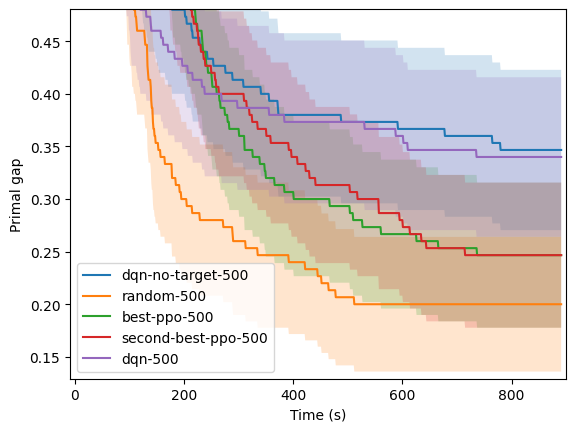

In [6]:
plot_by_bandit(df, metric="primal gap", x_axis="time")
plt.show()  